# Détection d'Alzheimer — Compétition M2 BDIA DL Project 2025

Ce notebook présente ma démarche pour résoudre la compétition Kaggle :  
**"M-2 BDIA DL Project 2025"**, dont l’objectif est de prédire les stades de la maladie d’Alzheimer à partir de données [...].

Dans ce notebook, nous allons :
- Explorer les données fournies
- Prétraiter les features
- Entraîner plusieurs modèles de Deep Learning
- Évaluer et comparer leurs performances
- Générer une soumission au format demandé



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import StackingClassifier



RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Importation des données

Dans cette section, on charge les fichiers `data.csv`, `test.csv`, etc., et on vérifie leurs dimensions et types.


In [4]:
# Load the training data
train_data = pd.read_csv('../data/data.csv')
# Load the test data
test_data = pd.read_csv('../data/test.csv',sep=';')

# Analyse Exploratoire

- Visualisation des distributions
- Recherche de valeurs manquantes
- Analyse des corrélations
- Identification des patterns potentiels

Cette étape permet de mieux comprendre la structure des données avant d’entraîner un modèle.


In [5]:
# Display Train basic information
print(f"\nDataset Shape: {train_data.shape}")
print(f"Number of features: {train_data.shape[1] - 1}")
print("\nFirst few rows:")
print(train_data.head())

# Check for missing values
print(f"\nMissing values: {train_data.isnull().sum().sum()}")


Dataset Shape: (104, 451)
Number of features: 450

First few rows:
   air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  max_x_extension1  \
0       4860     0.000013    236.876312      308.575985              3171   
1       2005     0.000010    174.435893      158.661271              1798   
2      12960     0.000019    154.094876       66.137920              1335   
3       7870     0.000012    102.981366       79.647541              1420   
4       3590     0.000009    241.464110      143.991636              1557   

   max_y_extension1  mean_acc_in_air1  mean_acc_on_paper1  mean_gmrt1  \
0              7348          0.277021            0.214148  272.726149   
1              5962          0.209676            0.125318  166.548582   
2              9809          0.303533            0.168974  110.116398   
3              6142          0.320674            0.156004   91.314453   
4              6218          0.220933            0.163247  192.727873   

   mean_jerk_in_air1  ...  mea

In [6]:
# Display basic information
print(f"\nDataset Shape: {test_data.shape}")
print(f"Number of features: {test_data.shape[1] }")
print("\nFirst few rows:")
print(test_data.head())

# Check for missing values
print(f"\nMissing values: {test_data.isnull().sum().sum()}")


Dataset Shape: (70, 450)
Number of features: 450

First few rows:
   air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  max_x_extension1  \
0       2130     0.000010    369.403342      183.193104              1756   
1       3525     0.000010    126.323599      139.596243              1046   
2       4695     0.000007    170.640009      141.200539              1715   
3       2635     0.000007    261.166647      147.334293              2099   
4       5705     0.000011    331.233476      156.489551              1039   

   max_y_extension1  mean_acc_in_air1  mean_acc_on_paper1  mean_gmrt1  \
0              8159          0.556879            0.164502  276.298223   
1              6118          0.225717            0.161174  132.959921   
2              5983          0.182334            0.144740  155.920274   
3              3936          0.620047            0.149459  204.250470   
4              7637          1.373276            0.140836  243.861514   

   mean_jerk_in_air1  ...  mean

In [7]:
# Identify columns

target_col = train_data.columns[-1]
feature_cols = train_data.columns[:-1]


print(f"Target Column: {target_col}")
print(f"Number of Feature Columns: {len(feature_cols)}")

Target Column: class
Number of Feature Columns: 450


In [8]:
# Class distribution
print("\n--- Class Distribution ---")
class_dist = train_data[target_col].value_counts()
print(class_dist)
print(f"\nClass Balance:")
print(f"Healthy (0): {class_dist[0]} ({class_dist[0]/len(train_data)*100:.1f}%)")
print(f"Patient (1): {class_dist[1]} ({class_dist[1]/len(train_data)*100:.1f}%)")


--- Class Distribution ---
class
1    65
0    39
Name: count, dtype: int64

Class Balance:
Healthy (0): 39 (37.5%)
Patient (1): 65 (62.5%)


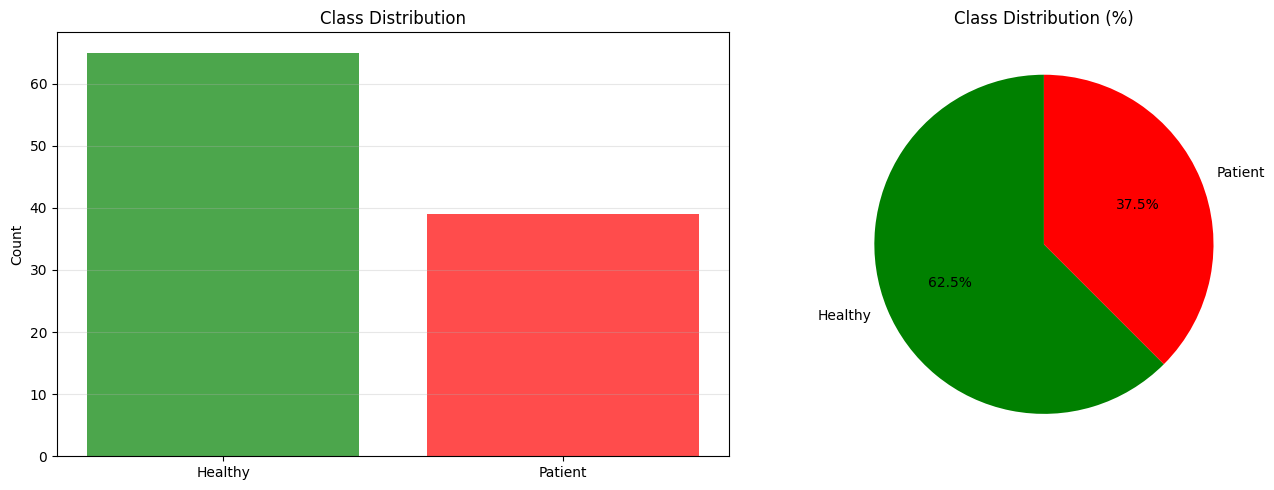

In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Healthy', 'Patient'], class_dist.values, color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(class_dist.values, labels=['Healthy', 'Patient'], autopct='%1.1f%%',
            colors=['green', 'red'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()


In [10]:
# Basic statistics
print("\n--- Feature Statistics ---")
X = train_data[feature_cols]
y = train_data[target_col]

print(f"Feature value ranges:")
print(f"Min: {X.min().min():.4f}")
print(f"Max: {X.max().max():.4f}")
print(f"Mean: {X.mean().mean():.4f}")
print(f"Std: {X.std().std():.4f}")



--- Feature Statistics ---
Feature value ranges:
Min: 0.0000
Max: 9206165.0000
Mean: 14044.2150
Std: 136543.5090


In [11]:
# Check for constant features
constant_features = [col for col in feature_cols if X[col].nunique() == 1]
print(f"\nConstant features: {len(constant_features)}")


Constant features: 0


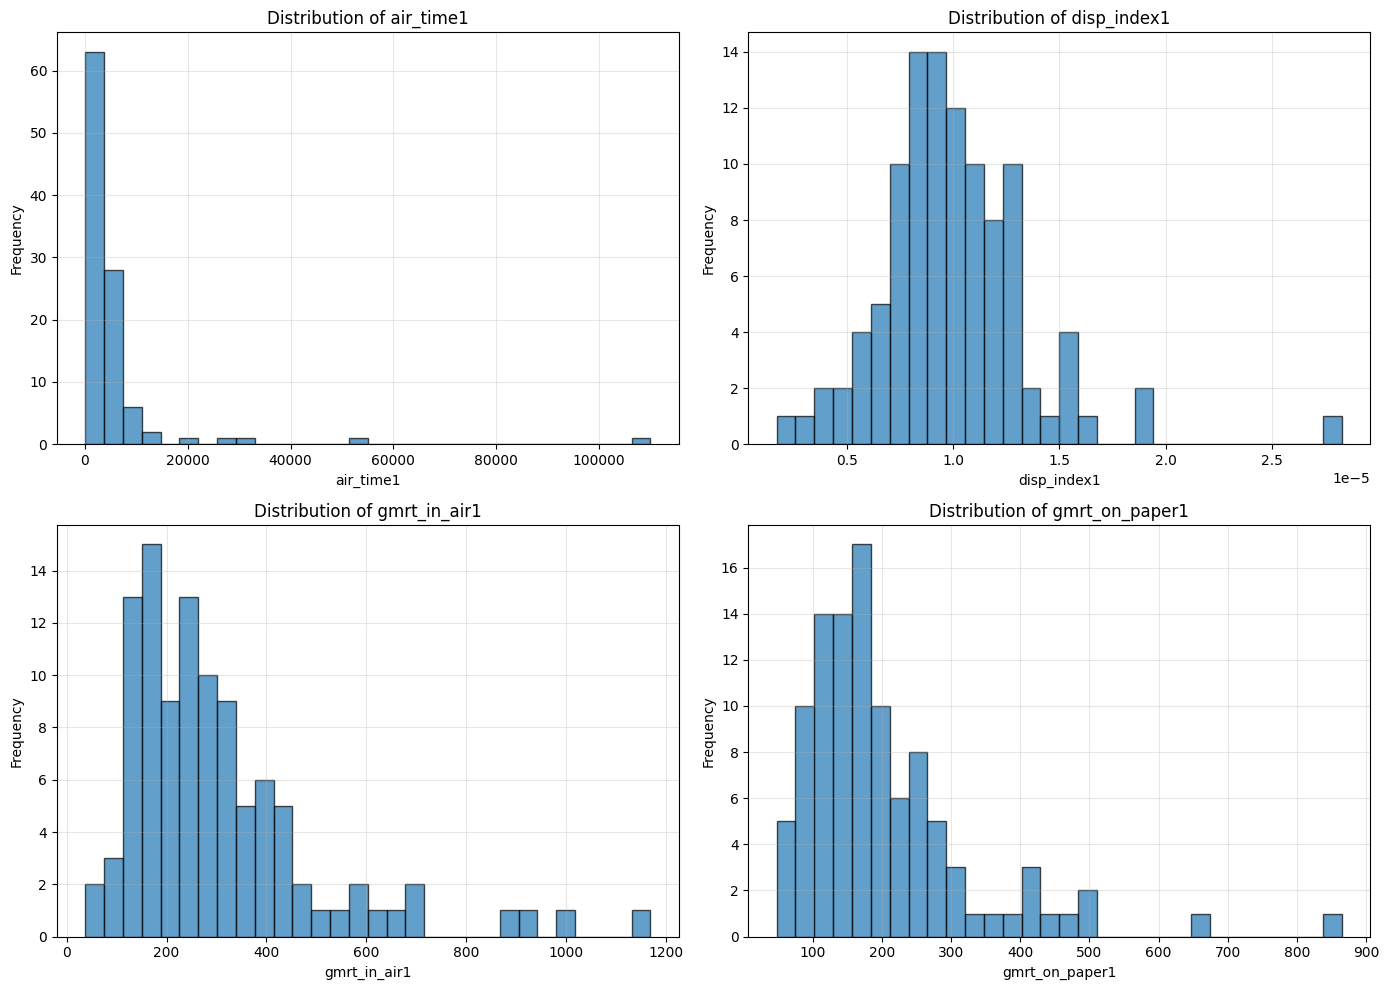

In [12]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sample_features = feature_cols[:4]

for idx, feat in enumerate(sample_features):
    ax = axes[idx//2, idx%2]
    ax.hist(X[feat], bins=30, alpha=0.7, edgecolor='black')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feat}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Correlation analysis
print("\n--- High Correlation Features ---")
correlation_matrix = X.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features (>0.95)
high_corr_features = [column for column in upper_triangle.columns
                      if any(upper_triangle[column] > 0.95)]
print(f"Features with correlation > 0.95: {len(high_corr_features)}")



--- High Correlation Features ---
Features with correlation > 0.95: 83



--- Feature Importance (Univariate) ---

Top 20 Features by F-statistic:
                  Feature      Score
116            mean_gmrt7  41.496427
110          gmrt_in_air7  35.725704
379          disp_index22  34.849001
296           mean_gmrt17  33.433766
299   mean_speed_in_air17  33.277519
119    mean_speed_in_air7  33.166669
443   mean_speed_in_air25  31.837156
53            total_time3  31.440066
294     mean_acc_in_air17  30.256202
297    mean_jerk_in_air17  29.763732
111        gmrt_on_paper7  29.720822
397          disp_index23  28.618039
290         gmrt_in_air17  28.224168
434         gmrt_in_air25  26.406411
233          total_time13  24.720615
440           mean_gmrt25  24.047104
407   mean_speed_in_air23  23.747852
291       gmrt_on_paper17  23.521828
120  mean_speed_on_paper7  22.666496
438     mean_acc_in_air25  22.241049


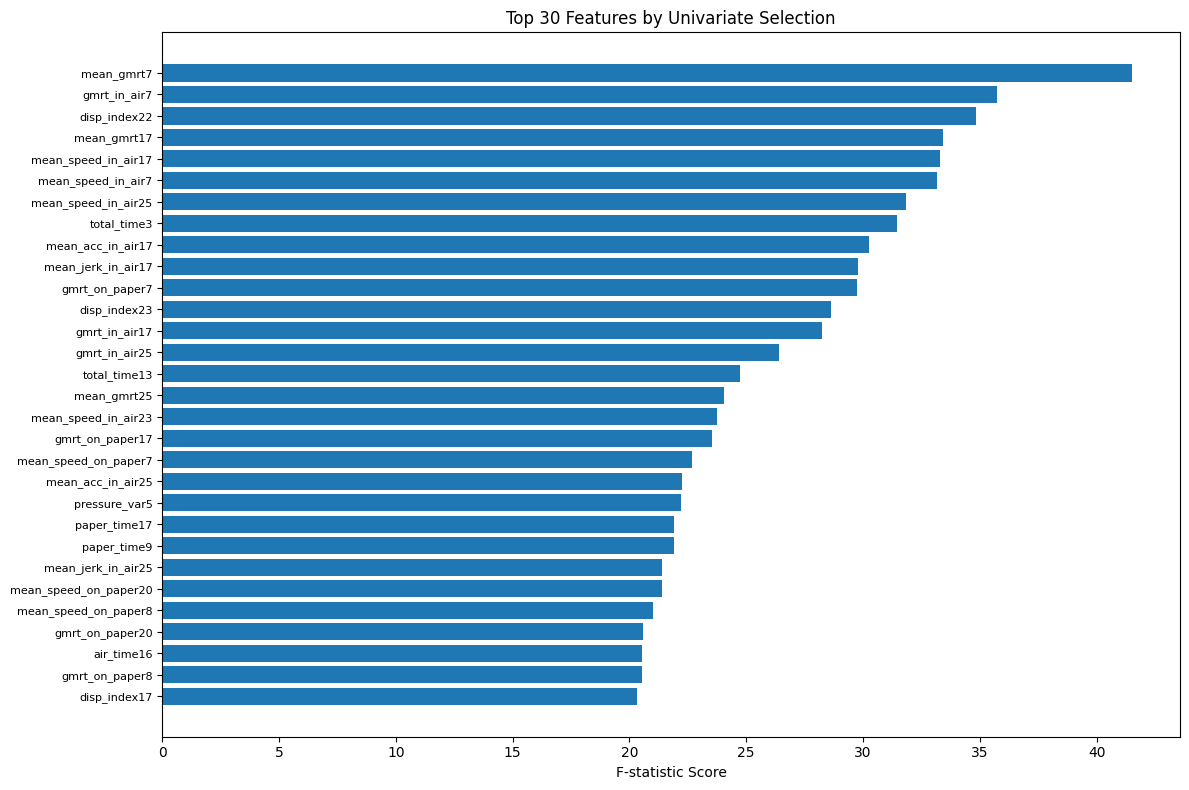

In [14]:
# Feature importance using univariate selection
print("\n--- Feature Importance (Univariate) ---")
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': feature_cols,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("\nTop 20 Features by F-statistic:")
print(feature_scores.head(20))

# Visualize top features
plt.figure(figsize=(12, 8))
top_n = 30
top_features = feature_scores.head(top_n)
plt.barh(range(top_n), top_features['Score'].values)
plt.yticks(range(top_n), top_features['Feature'].values, fontsize=8)
plt.xlabel('F-statistic Score')
plt.title(f'Top {top_n} Features by Univariate Selection')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

# Prétraitement

Ici, je nettoie et prépare les données :

- Normalisation / Standardisation
- Encodage des variables
- Séparation train/validation
- Création éventuelle de nouvelles features

In [15]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_test=test_data.copy()

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")


Training set: (83, 450)
Validation set: (21, 450)


#ACP

In [16]:
pca = PCA(n_components=80)   # garder 95% de l'information
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

print(X_train_pca.shape)

(83, 80)


In [17]:
X_test_pca = pca.transform(X_test)
print(X_test_pca.shape)

(70, 80)


#Standar Scaler


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled_pca = scaler.fit_transform(X_train_pca)
X_val_scaled_pca = scaler.transform(X_val_pca)


In [19]:
X_test_scaled_pca = scaler.transform(X_test_pca)

In [20]:
pd.DataFrame(X_train_scaled_pca).head()

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,4.440966,0.341999,-0.006823,-0.536640,0.192280,-0.639991,-0.354817,-0.760803,-0.780760,0.008937,...,1.173558,2.298710,-0.488462,2.288473,-1.249661,0.677605,0.823686,-1.001754,0.662400,0.122436
1,-0.236325,-0.192649,-0.337276,-2.009008,-0.287941,0.694247,-0.939613,-0.317648,1.203767,-0.615226,...,0.206732,0.759711,0.813375,0.590032,0.092703,0.657115,0.641670,0.848095,3.438244,1.725244
2,-0.230805,-0.091004,-0.011111,0.563096,0.486936,-0.619917,1.841774,1.100204,1.287018,0.605266,...,-0.902211,-1.821335,0.342852,0.438522,-0.510989,-1.605322,0.353404,-1.175826,-0.042888,-0.248509
3,-0.235888,-0.185918,-0.107946,-1.046014,-0.032321,-0.370550,-0.296180,-0.692842,0.173973,0.351259,...,-0.167209,-1.530940,0.315157,-0.482564,-1.642782,1.615738,-0.519688,0.851110,0.224061,-0.422826
4,-0.235846,-0.067187,-0.255957,-0.538897,-0.206483,0.744182,0.225715,-1.083810,0.048563,-0.543736,...,-1.388904,0.278612,-1.363445,0.353424,1.395332,0.078648,2.055302,0.360724,-0.227026,-0.075574


In [21]:
pd.DataFrame(X_test_scaled_pca).head()

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,-0.202328,0.009138,0.147649,2.312180,-0.412464,-0.978646,0.793647,0.086338,0.618416,1.152879,...,3.361369,-3.324448,7.522509,4.516379,1.673241,0.871721,-3.146871,-8.059009,-4.119148,-2.382148
1,-0.239307,-0.038965,0.110900,0.458411,0.680172,-0.108705,0.923007,0.511931,-0.038460,-0.197313,...,-0.297241,-8.464252,8.282552,13.087163,10.304561,8.496649,8.142215,19.691333,-10.659040,-8.785820
2,-0.146938,-0.176293,-0.076249,0.472432,-0.150825,0.316739,-0.292617,-0.455674,1.018959,-0.185966,...,0.242535,-3.537168,5.384079,-4.695737,-0.460214,-7.422822,3.359173,-3.723646,19.157829,8.926096
3,-0.217555,-0.187851,-0.090244,0.615982,-0.602117,0.309069,0.167778,-0.166763,1.707057,-0.360409,...,-2.935874,-3.198777,8.877961,4.727021,11.457518,-1.592626,-0.700682,-2.668768,9.060213,-5.159546
4,-0.237744,-0.169032,-0.130152,0.069709,-0.035841,-0.242489,-0.570508,-0.058506,-0.728808,0.267286,...,2.489223,-1.820375,5.680962,3.090669,-0.498552,-2.561577,-1.170977,-0.665822,-2.468699,-0.290034


# Models


#Cat Boost Classifier

In [22]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3,
    subsample=0.9,
    random_strength=1.5,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=200,
    random_seed=42
)


#XGBoost Classifier

In [23]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(
    n_estimators=900,
    learning_rate=0.02,
    max_depth=4,
    min_child_weight=1.5,
    subsample=0.9,
    colsample_bytree=0.75,
    gamma=0.15,
    reg_alpha=0.4,
    reg_lambda=2.0,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    booster='gbtree',
    n_jobs=-1,
    random_state=42
)

#LGBM Classifier

In [24]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.0,
    objective="binary",
    random_state=42,
    n_jobs=-1
)

#ExtraTreesClassifier

In [25]:
from sklearn.ensemble import ExtraTreesClassifier

model_extra = ExtraTreesClassifier(
    n_estimators=1000,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=True,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)


#RandomForestClassifier

In [26]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=3,
    min_samples_leaf=2,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


#BaggingClassifier with DecisionTreeClassifier

In [27]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

model_bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ),
    n_estimators=200,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

#SVC

In [28]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel='rbf',
    C=3,
    gamma='scale',
    probability=True
)


#pipeline

In [29]:
preprocessor = StandardScaler() 
stacking = StackingClassifier(
        estimators=[
        ('xgb', model_xgb),
        ('lgb', model_lgb),
        ('cat', model_cat),
        ('extra', model_extra),
        ('rf', model_rf ),
        ('bagging', model_bag),
        ('svm', model_svm),
        
    ],
        final_estimator=CatBoostClassifier(
            iterations=800,
            max_depth=6,
            learning_rate=0.03,
            verbose=0
        ),
        stack_method='predict_proba',
        passthrough=True,    # très important !
        cv=10,               # haut niveau
        n_jobs=-1
)

In [30]:
pipeline = Pipeline(steps=[
    ("scaler", preprocessor),
    ("stack", stacking)
])

In [31]:
pipeline.fit(X_train_scaled_pca, y_train)

,steps,"[('scaler', ...), ('stack', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimators,"[('xgb', ...), ('lgb', ...), ...]"
,final_estimator,<catboost.cor...0023534948510>
,cv,10
,stack_method,'predict_proba'


In [32]:
preds_try = pipeline.predict_proba(X_val_scaled_pca)[:, 1]

c:\Users\nader\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Evaluation 

In [33]:
# ROC AUC
roc_auc = roc_auc_score(y_val, preds_try)
print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.7692307692307692


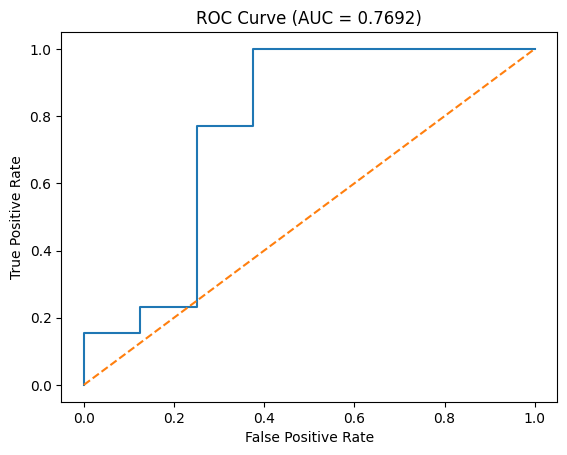

In [34]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_val, preds_try)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# Prediction 

In [35]:
preds= pipeline.predict_proba(X_test_scaled_pca)[:, 1]

c:\Users\nader\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
submission = pd.DataFrame({
    "ID": range(len(preds)),
    "Target": preds
})

submission.to_csv("submission.csv", index=False)
print("✓ submission.csv généré")

✓ submission.csv généré
